## Importovanie knižníc

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Analýza štruktúr dát ako súbory

Dataset sa skladá z 3 csv súborov `units.csv`, `readings.csv`, `gateways.csv`

## Readings.csv

### 1.1A - Analýza štruktúr dát

#### Súbor

- **Počet záznamov:** 14495
- **Počet atribútov:** 11
- **Index:** `RangeIndex` 0 – 14494
- **Delimiter:** \t
- **Obsah:** merania senzorov z Air-Production-Unit (APU) vlaku, kde každý riadok je jedno meranie jednej jednotky `id_unit` v čase `ts_cycle`


#### Atribúty

| Atribút | Dtype | Non-null | Chýba | Popis |
|---|---|---|---|---|
| `id_unit` | str -> int64 | 14 495 | 0 | ID jednotky (APU) |
| `ts_cycle` | str -> datetime64 | 14 495 | 0 | Timestamp merania |
| `motor_current` | float64 | 14 495 | 0 | Prúd motora kompresora |
| `dpFilter` | float64 | 13 935 | 560 | Diferenčný tlak (podľa googlu) - indikuje zanášanie filtra |
| `temperature_oil` | float64 | 14 495 | 0 | Teplota oleja |
| `reservoirPressure` | float64 | 14 495 | 0 | Tlak v zásobníku |
| `oilPressure` | float64 | 14 495 | 0 | Tlak oleja |
| `rms_vibration` | float64 | 13 930 | 565 | Podľa wikipédie "Efektívna hodnota" vibrácií |
| `Flowmeter` | float64 | 14 495 | 0 | Prietok |
| `humidityIntake` | float64 | 13 790 | 705 | Vlhkosť nasávaného vzduchu |
| `failure` | int64 | 14 495 | 0 | Indikátor poruchy - predikovaná premenná. Teoreticky by to mohol byť `boolean`|


 Stĺpec *ts_cycle* obsahoval zmiešané formáty dátumov a časov, takže sme ich zjednotili pomocou parametra `parse_dates` vo funkcii `read_csv`. Okrem toho sme chceli zjednotiť ID APU *id_unit* medzi súbormi, tak sme ho prekonvertovali na `int` po odstránení "U" zo začiatku stringu.


In [5]:
READINGS = "readings.csv"
readings_df = pd.read_csv(READINGS, delimiter="\t", parse_dates=["ts_cycle"], date_format="mixed")

readings_df["id_unit"] = readings_df["id_unit"].str.replace("U", "").astype(int)

readings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14495 entries, 0 to 14494
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_unit            14495 non-null  int64         
 1   ts_cycle           14495 non-null  datetime64[us]
 2   motor_current      14495 non-null  float64       
 3   dpFilter           13935 non-null  float64       
 4   temperature_oil    14495 non-null  float64       
 5   reservoirPressure  14495 non-null  float64       
 6   oilPressure        14495 non-null  float64       
 7   rms_vibration      13930 non-null  float64       
 8   Flowmeter          14495 non-null  float64       
 9   humidityIntake     13790 non-null  float64       
 10  failure            14495 non-null  int64         
dtypes: datetime64[us](1), float64(8), int64(2)
memory usage: 1.2 MB


## Units.csv

### 1.1A - Analýza štruktúr dát

#### Súbor

- **Počet záznamov:** 2000
- **Počet atribútov:** 7
- **Index:** `RangeIndex` 0 – 1999
- **Delimiter:** ,
- **Obsah:** údaje o jednotkách APU. Nemenia sa v čase, tak uvidíme ešte ako relevantné pre nás budú `year_commision`, `dutyClass` alebo `hours_service`

#### Atribúty

| Atribút | Dtype | Non-null | Chýba | Popis |
|---|---|---|---|---|
| `id_unit` | int64 | 2 000 | 0 | Identifikátor jednotky APU, prepojenie so súborom `readings.csv` |
| `serial_number` | str | 2 000 | 0 | Sériové číslo jednotky |
| `year_commission` | int64 | 2 000 | 0 | Rok uvedenia do prevádzky |
| `dutyClass` | str | 2 000 | 0 | Trieda zaťaženia - kategorická premenná |
| `hours_service` | float64 | 1 900 | 100 | Počet prevádzkových hodín |
| `operatorOwner` | str | 2 000 | 0 | Prevádzkovateľ / vlastník |
| `idDepot` | int64 | 2 000 | 0 | Identifikátor depa |

Stĺpec *dutyClass* obsahuje rôzne pomenovania pre pravdepodobne rovnaké kategórie, no zatiaľ nevieme ktoré môžme zlúčiť.

In [6]:
UNITS = "units.csv"
units_df = pd.read_csv(UNITS, delimiter=",")

units_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_unit          2000 non-null   int64  
 1   serial_number    2000 non-null   str    
 2   year_commission  2000 non-null   int64  
 3   dutyClass        2000 non-null   str    
 4   hours_service    1900 non-null   float64
 5   operatorOwner    2000 non-null   str    
 6   idDepot          2000 non-null   int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 167.2 KB


## Gateways.csv

### 1.1A - Analýza štruktúr dát

#### Súbor

- **Počet záznamov:** 2000
- **Počet atribútov:** 14
- **Index:** `RangeIndex` 0 – 1999
- **Delimiter:** ;
- **Obsah:** údaje o komunikačných bránach (routeroch). Myslíme si, že tieto dáta budú skoro úplne nepodstatné pre naše predikcie

#### Atribúty

| Atribút | Dtype | Non-null | Chýba | Popis |
|---|---|---|---|---|
| `gatewayId` | str | 2 000 | 0 | Identifikátor brány |
| `id_unit` | float64 -> int64 | 2 000 | 0 | ID jednotky APU, ku ktorej brána patrí - foreign key|
| `idDepot` | int64 | 2 000 | 0 | Identifikátor depa |
| `lat` | float64 | 2 000 | 0 | Zemepisná šírka |
| `Lon` | float64 | 2 000 | 0 | Zemepisná dĺžka |
| `model_hardware` | str | 2 000 | 0 | Model hardvéru |
| `version_firmware` | str | 2 000 | 0 | Verzia firmvéru |
| `vendor` | str | 2 000 | 0 | Výrobca / dodávateľ |
| `Technician` | str | 2 000 | 0 | Technik, ktorý bránu inštaloval |
| `mac_address` | str | 2 000 | 0 | MAC adresa brány |
| `Ipv4` | str | 2 000 | 0 | IPv4 adresa brány |
| `dbm_signal` | float64 | 2 000 | 0 | Sila signálu v dBm |
| `dateInstall` | str -> datetime64 | 2 000 | 0 | Dátum inštalácie brány |
| `last_seen` | str -> datetime64 | 2 000 | 0 | Posledné zaznamenané spojenie brány |


Stĺpce *last_seen* a *dateInstall* oba používajú nejednotné formáty času, tak sme sa ich rozhodli zjednotiť.
Z povahy dát usudzujeme, že stĺpec *id_unit* bude značiť ID jednotky APU, do ktorej bola daný smerovač osadený. Ak smerovač ID APU nemá, znamená to že ho nevieme k žiadnemu priradiť a je pre nás irelevantný -> `dropna`. 
Stĺpec *id_unit* bol uložený ako typ `float`, tak sme ho prekonvertovali na typ `int`.

In [7]:
GATEWAYS = "gateways.csv"
gateways_df = pd.read_csv(GATEWAYS, delimiter=";", parse_dates=["last_seen", "dateInstall"], date_format="mixed")

gateways_df = gateways_df.dropna(subset="id_unit")
gateways_df["id_unit"] = gateways_df.id_unit.astype(int)

gateways_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gatewayId         2000 non-null   str           
 1   lat               2000 non-null   float64       
 2   model_hardware    2000 non-null   str           
 3   version_firmware  2000 non-null   str           
 4   Technician        2000 non-null   str           
 5   mac_address       2000 non-null   str           
 6   idDepot           2000 non-null   int64         
 7   id_unit           2000 non-null   int64         
 8   vendor            2000 non-null   str           
 9   Lon               2000 non-null   float64       
 10  Ipv4              2000 non-null   str           
 11  last_seen         2000 non-null   datetime64[us]
 12  dbm_signal        2000 non-null   float64       
 13  dateInstall       2000 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(3), i

Pre každú tabuľku skontrolujeme či sa vyskytujú duplicitné riadky a koľko ich je.

In [8]:
print(f"duplicitné riadky v readings: {readings_df.duplicated().sum()}")
print(f"duplicitné riadky v units: {units_df.duplicated().sum()}")
print(f"duplicitné riadky v gateways: {gateways_df.duplicated().sum()}")

duplicitné riadky v readings: 214
duplicitné riadky v units: 0
duplicitné riadky v gateways: 0


## Vzťahy medzi súbormi
Súbory sú prepojené pomocu atribútov `id_unit` a `idDepot`. 

### `id_unit`
Každý súbor obsahuje atribút `id_unit`. V súbore `units.csv` je identifikátor jednotky APU čiže je primárny kľúč, v súboroch `readings.csv` a `gateways.csv` je to cudzí kľúč.  Merania z `readings.csv` sú teda priradené k jednotkám APU z `units.csv` a jednotky APU sú priradené k bránam z `gateways.csv`.

In [9]:
reading_units_ids = set(readings_df["id_unit"])
units_ids = set(units_df["id_unit"])
print("ID v readings, ktoré nie sú v units:", len(reading_units_ids - units_ids))
print("ID v units, ktoré nie sú v readings:", len(units_ids - reading_units_ids))

ID v readings, ktoré nie sú v units: 125
ID v units, ktoré nie sú v readings: 3


V readings sa nachádzajú ID jednotiek, ktoré sa nenachádzajú v units. Tieto ID jednotiek sú pravdepodobne chybné a mali by sme ich odstrániť z readings. Takisto môžeme vydieť, že v units sa nachádzajú ID jednotiek, ktoré sa nenachádzajú v readings. Tieto jednotky APU pravdepodobne neboli nikdy zapnuté a teda nemali by sme ich zahrnúť do predikcií.

### `idDepot`

In [10]:
units_id_depot = set(units_df["idDepot"])
gateways_id_depot = set(gateways_df["idDepot"])
print("ID v units, ktoré nie sú v gateways:", len(units_id_depot - gateways_id_depot))
print("ID v gateways, ktoré nie sú v units:", len(gateways_id_depot - units_id_depot))
gateways_ids = set(gateways_df["id_unit"])
print("ID v units, ktoré nie sú v gateways:", len(units_ids - gateways_ids))
print("ID v gateways, ktoré nie sú v units:", len(gateways_ids - units_ids))

ID v units, ktoré nie sú v gateways: 0
ID v gateways, ktoré nie sú v units: 0
ID v units, ktoré nie sú v gateways: 0
ID v gateways, ktoré nie sú v units: 0


Riadky z `units.csv` a `gateways.csv` sú 1 k 1 prepojené aj pomocou atribútu `idDepot` aj `id_unit`.

# Analýza jednotlivých atribútov

Z tabuľky `readings` sme sa rozhodli analyzovať všetky atribúty okrem `id_unit`, `ts_cycle` a `failure`, pretože tieto atribúty sú identifikátory a predikovaná premenná.
Z tabuľky `units` budeme analyzovať atribúty `year_commission`, `dutyClass` a `hours_service`, pretože môžu byť relevantné pre predikciu poruchy jednotky APU. Z tabuľky `gateways` nebudeme analyzovať žiadne atribúty, pretože sa nám zdajú byť irelevantné.

### Rozdelenie analyzovaných atribútov na numerické a kategorické

Numericke atribúty z readings sú: `motor_current`, `dpFilter`, `temperature_oil`, `reservoirPressure`, `oilPressure`, `rms_vibration`, `Flowmeter`, `humidityIntake`.

Numericke atribúty z units sú: `year_commission`, `hours_service`.
Kategorický atribút z units je: `dutyClass`.

#### Numerické atribúty

In [11]:
def get_numeric_summary(df, numeric_cols):
    summary = df[numeric_cols].describe().T
    summary["missing"] = df[numeric_cols].isna().sum()
    summary["missing_percent"] = (
        summary["missing"] / len(df) * 100
    )
    return summary

readings_numeric_cols = [
    "motor_current",
    "dpFilter",
    "temperature_oil",
    "reservoirPressure",
    "oilPressure",
    "rms_vibration",
    "Flowmeter",
    "humidityIntake"
]

get_numeric_summary(readings_df, readings_numeric_cols)

,count,mean,std,min,25%,50%,75%,max,missing,missing_percent
motor_current,14495.0,5.330016,3.771726,0.27513,3.747675,5.115780,6.625020,99.00000,0,0.000000
dpFilter,13935.0,24.048845,11.345637,7.11703,16.310395,21.386830,28.729445,120.00000,560,3.863401
temperature_oil,14495.0,52.291470,56.598579,-999.00000,46.916660,55.090090,63.397335,95.00000,0,0.000000
reservoirPressure,14495.0,8.693509,0.604008,6.50000,8.286835,8.700030,9.101190,10.50000,0,0.000000
oilPressure,14495.0,3.694307,0.568678,1.50000,3.316100,3.693540,4.074520,6.00000,0,0.000000
rms_vibration,13930.0,3.072725,1.605018,0.50000,1.957050,2.735460,3.786735,14.00000,565,3.897896
Flowmeter,14495.0,27.968398,4.013177,15.00000,25.260900,27.948010,30.722515,40.00000,0,0.000000
humidityIntake,13790.0,52.106943,24.422992,10.01145,30.802845,51.822225,73.280355,94.99296,705,4.863746


In [12]:
units_numeric_cols = ["hours_service", "year_commission"]
get_numeric_summary(units_df, units_numeric_cols)

,count,mean,std,min,25%,50%,75%,max,missing,missing_percent
hours_service,1900.0,14202.477211,8463.701772,1553.1,8183.3,12122.6,17884.625,45000.0,100,5.0
year_commission,2000.0,2020.450500,2.405919,2012.0,2019.0,2021.0,2022.000,2024.0,0,0.0


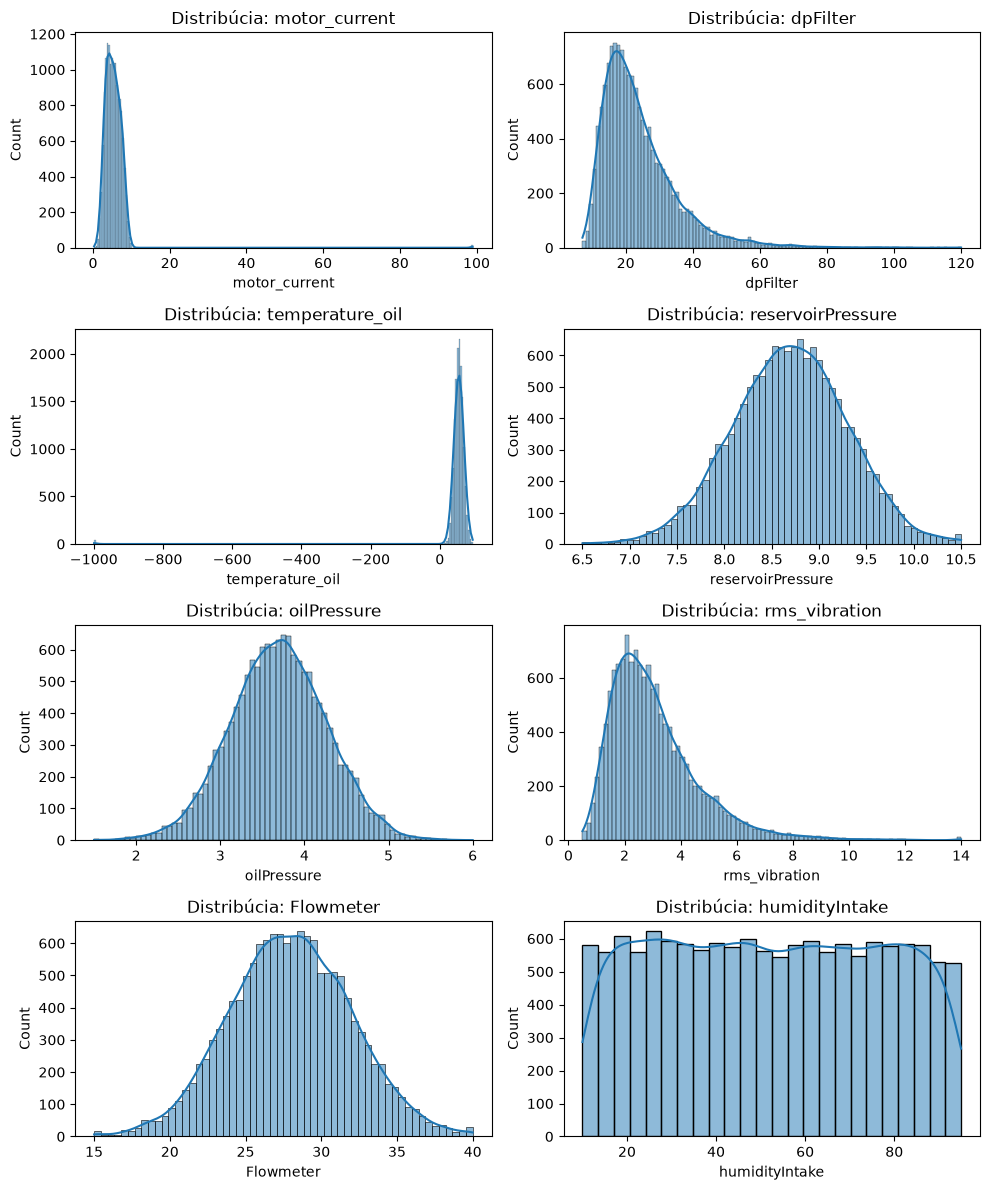

In [13]:
def plot_numeric_distributions(df, numeric_cols, rows, cols, figsize):
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()

    for ax, column in zip(axes, numeric_cols):
        sns.histplot(data=df, x=column, kde=True, ax=ax)
        ax.set_title(f"Distribúcia: {column}")

    plt.tight_layout()
    plt.show()
plot_numeric_distributions(readings_df, readings_numeric_cols, rows=4, cols=2, figsize=(10, 12))

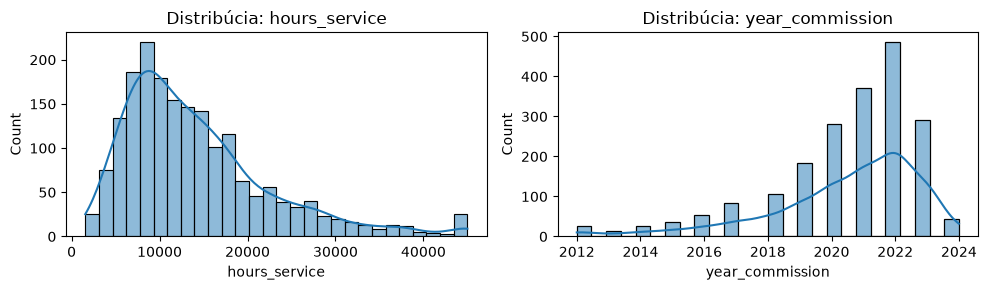

In [14]:
plot_numeric_distributions(units_df, units_numeric_cols, rows=1, cols=2, figsize=(10, 3))

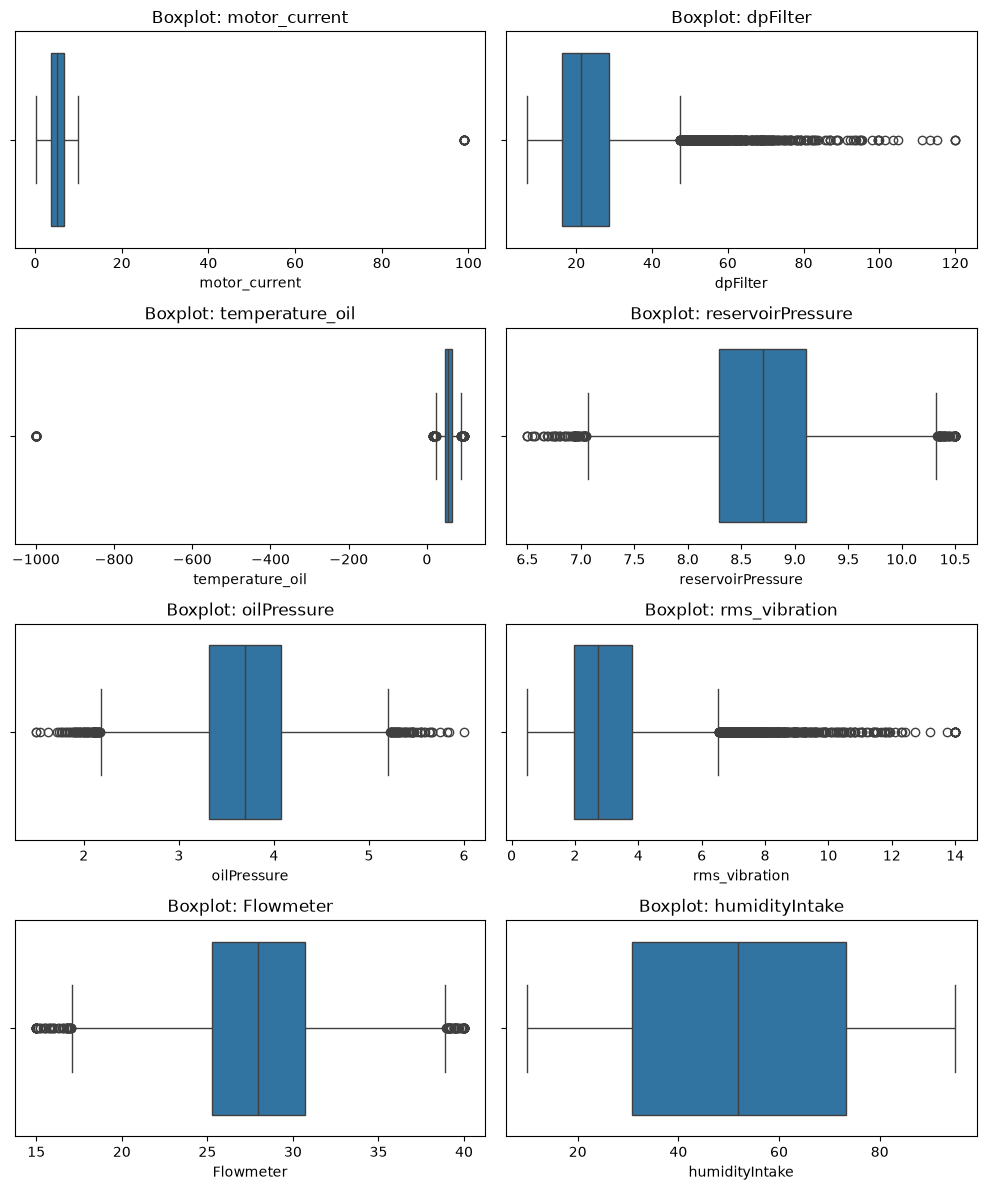

In [15]:
def plot_numeric_distributions(df, numeric_cols, rows, cols, figsize):
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()

    for ax, column in zip(axes, numeric_cols):
        sns.boxplot(data=df, x=column, ax=ax)
        ax.set_title(f"Boxplot: {column}")

    plt.tight_layout()
    plt.show()

plot_numeric_distributions(readings_df, readings_numeric_cols, rows=4, cols=2, figsize=(10, 12))

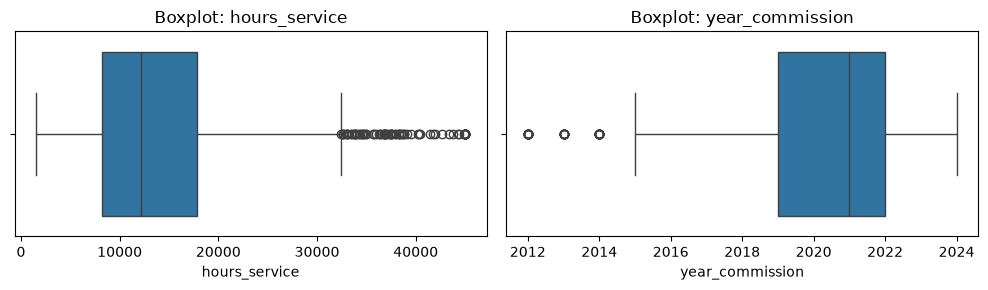

In [16]:
plot_numeric_distributions(units_df, units_numeric_cols, rows=1, cols=2, figsize=(10, 3))

#### `motor_current`
Hodnoty prúdu motora sa primárne nachádzajú približne v rozsahu od 0 do 10, pričom najväčšia koncentrácia hodnôt je približne medzi 3 a 7. Medián je  5,12 a priemer 5,33. Maximálna hodnota je 99 čo je pravdepodobne outlier. Na histograme sú hodnoty koncentrované v dolnej časti rozsahu a pravostranné vychýlenie je spôsobené jednou vysokou odľahlou hodnotou.
Boxplot takisto odhaľuje výraznú odľahlú hodnotu 99. 

#### `dpFilter`
Atribút `dpFilter` nadobúda hodnoty od 7,12 do 120. Väčšina hodnôt sa nachádza približne medzi 15 a 40, pričom medián je 21,39. Histogram je výrazne pravostranný – najviac hodnôt sa nachádza v nižšom rozsahu a smerom k vyšším hodnotám sa vytvára dlhý chvost. Boxplot zobrazuje veľké množstvo odľahlých hodnôt nad hornou hranicou bežného rozsahu. Môže ísť o skutočne zvýšený tlak na filtri, ale aj o chybné alebo abnormálne merania. Atribút obsahuje 560 chýbajúcich hodnôt, čo predstavuje približne 3,9 % záznamov.

#### `temperature_oil`
Väčšina hodnôt teploty oleja sa nachádza približne medzi 45 a 65, pričom medián je 55,09 °C. Histogram ukazuje pomerne úzke a približne symetrické rozdelenie okolo hodnôt približne 50 až 60 °C.
Rozdelenie je skreslené hodnotou -999, ktorá sa nachádza ďaleko od ostatných hodnôt a je zobrazená ako extrémna odľahlá hodnota aj v boxplote.

#### `reservoirPressure`
Tlak v zásobníku sa pohybuje v rozsahu od 6,5 do 10,5, pričom medián a priemer je približne 8,70. Histogram má  symetrický tvar. Boxplot ukazuje niekoľko odľahlých hodnôt na oboch stranách rozdelenia. Tieto hodnoty však nie sú výrazne vzdialené.

#### `oilPressure`
Hodnoty tlaku oleja sa nachádzajú v rozsahu od 1,5 do 6,0, pričom medián je 3,69. Histogram má  symetrický tvar s najväčšou koncentráciou hodnôt medzi 3 a 4,5. Boxplot ukazuje odľahlé hodnoty na oboch stranách rozdelenia. Rozdelenie je pomerne pravidelné a bez výraznej deformácie.

#### `rms_vibration`
Hodnota sa pohybuje od 0,5 do 14, pričom väčšina hodnôt sa nachádza približne medzi 1,5 a 4. Medián je 2,74 a priemer 3,07. Histogram je pravostranný a ukazuje, že väčšina hodnôt je koncentrovaná v nižšom rozsahu, pričom sa vytvára dlhý chvost smerom k vyšším hodnotám. Boxplot zobrazuje veľké množstvo odľahlých hodnôt nad hornou hranicou bežného rozsahu. Tieto odľahlé hodnoty môžu predstavovať abnormálny stav jednotky. Atribút obsahuje 565 chýbajúcich hodnôt, teda 3,9 % záznamov.

#### `Flowmeter`
Hodnoty sa nachádzajú v rozsahu 15 až 40, pričom medián a priemer je 27,9. Histogram má  pomerne symetrický tvar. Najviac hodnôt sa nachádza približne medzi 25 a 31. Boxplot ukazuje niekoľko odľahlých hodnôt na dolnom aj hornom konci rozsahu. Tieto hodnoty však nie sú extrémne vzdialené od hlavného rozdelenia. Atribút neobsahuje chýbajúce hodnoty.

#### `humidityIntake`
Vlhkosť nasávaného vzduchu sa pohybuje približne od 10 do 95 %, pričom medián je 51,82 %. Histogram pôsobí pomerne rovnomerne – hodnoty sú rozmiestnené v širokom intervale bez jedného výrazného vrcholu.Boxplot nevykazuje výrazné odľahlé hodnoty. Rozdelenie je preto v porovnaní s ostatnými atribútmi pomerne rovnomerné. Atribút obsahuje 705 chýbajúcich hodnôt, čo predstavuje približne 4,9 % záznamov.
Predpokladáme, že tento parameter je skôr ovplivnený počasím a prostredím, než samotnou jednotkou APU, takže nemusí byť relevantný pre predikciu poruchy.

#### `hours_service`
Počet prevádzkových hodín sa pohybuje približne od 1 553 do 45 000 hodín. Medián je približne 12 123 hodín, zatiaľ čo priemer je vyšší, približne 14 202 hodín. Rozdiel medzi priemerom a mediánom súvisí s pravostranným vychýlením rozdelenia. Histogram ukazuje, že najviac jednotiek má približne 5 000 až 20 000 prevádzkových hodín. S rastúcim počtom hodín počet jednotiek postupne klesá, pričom sa objavuje dlhý chvost až k hodnote 45 000. Boxplot zobrazuje viacero odľahlých hodnôt nad približne 33 000 hodinami. Atribút obsahuje 100 chýbajúcich hodnôt, teda 5 % záznamov.

#### `year_commission`
Rok uvedenia jednotky do prevádzky sa nachádza v intervale od 2012 do 2024. Medián je 2021 a priemer je 2020,45. Histogram ukazuje, že najviac jednotiek bolo uvedených do prevádzky v rokoch približne 2019 až 2023, pričom najvyšší počet je pri roku 2022.Staršie roky, najmä 2012 až 2014, sa vyskytujú iba v malom počte. Boxplot ich preto označuje ako odľahlé hodnoty.

In [20]:
#sns.regplot(x="temperature_oil", y="motor_current", data=readings_df)
readings_df.corr(numeric_only=True)

,id_unit,motor_current,dpFilter,temperature_oil,reservoirPressure,oilPressure,rms_vibration,Flowmeter,humidityIntake,failure
id_unit,1.000000,-0.005993,-0.008811,-0.005163,-0.011226,-0.013090,0.003375,0.018597,0.003939,0.004211
motor_current,-0.005993,1.000000,-0.005366,0.001456,0.005442,0.001033,-0.011077,0.004986,0.000332,-0.026730
dpFilter,-0.008811,-0.005366,1.000000,-0.007469,-0.001820,0.002486,-0.008384,-0.002913,-0.005123,0.102417
temperature_oil,-0.005163,0.001456,-0.007469,1.000000,0.002653,0.004862,-0.005754,-0.000555,-0.001578,-0.017525
reservoirPressure,-0.011226,0.005442,-0.001820,0.002653,1.000000,0.849409,0.003243,-0.003968,0.009656,-0.077128
oilPressure,-0.013090,0.001033,0.002486,0.004862,0.849409,1.000000,0.003987,-0.013027,0.004918,-0.065281
rms_vibration,0.003375,-0.011077,-0.008384,-0.005754,0.003243,0.003987,1.000000,0.006305,0.005603,0.028479
Flowmeter,0.018597,0.004986,-0.002913,-0.000555,-0.003968,-0.013027,0.006305,1.000000,-0.002360,-0.035392
humidityIntake,0.003939,0.000332,-0.005123,-0.001578,0.009656,0.004918,0.005603,-0.002360,1.000000,0.001533
failure,0.004211,-0.026730,0.102417,-0.017525,-0.077128,-0.065281,0.028479,-0.035392,0.001533,1.000000


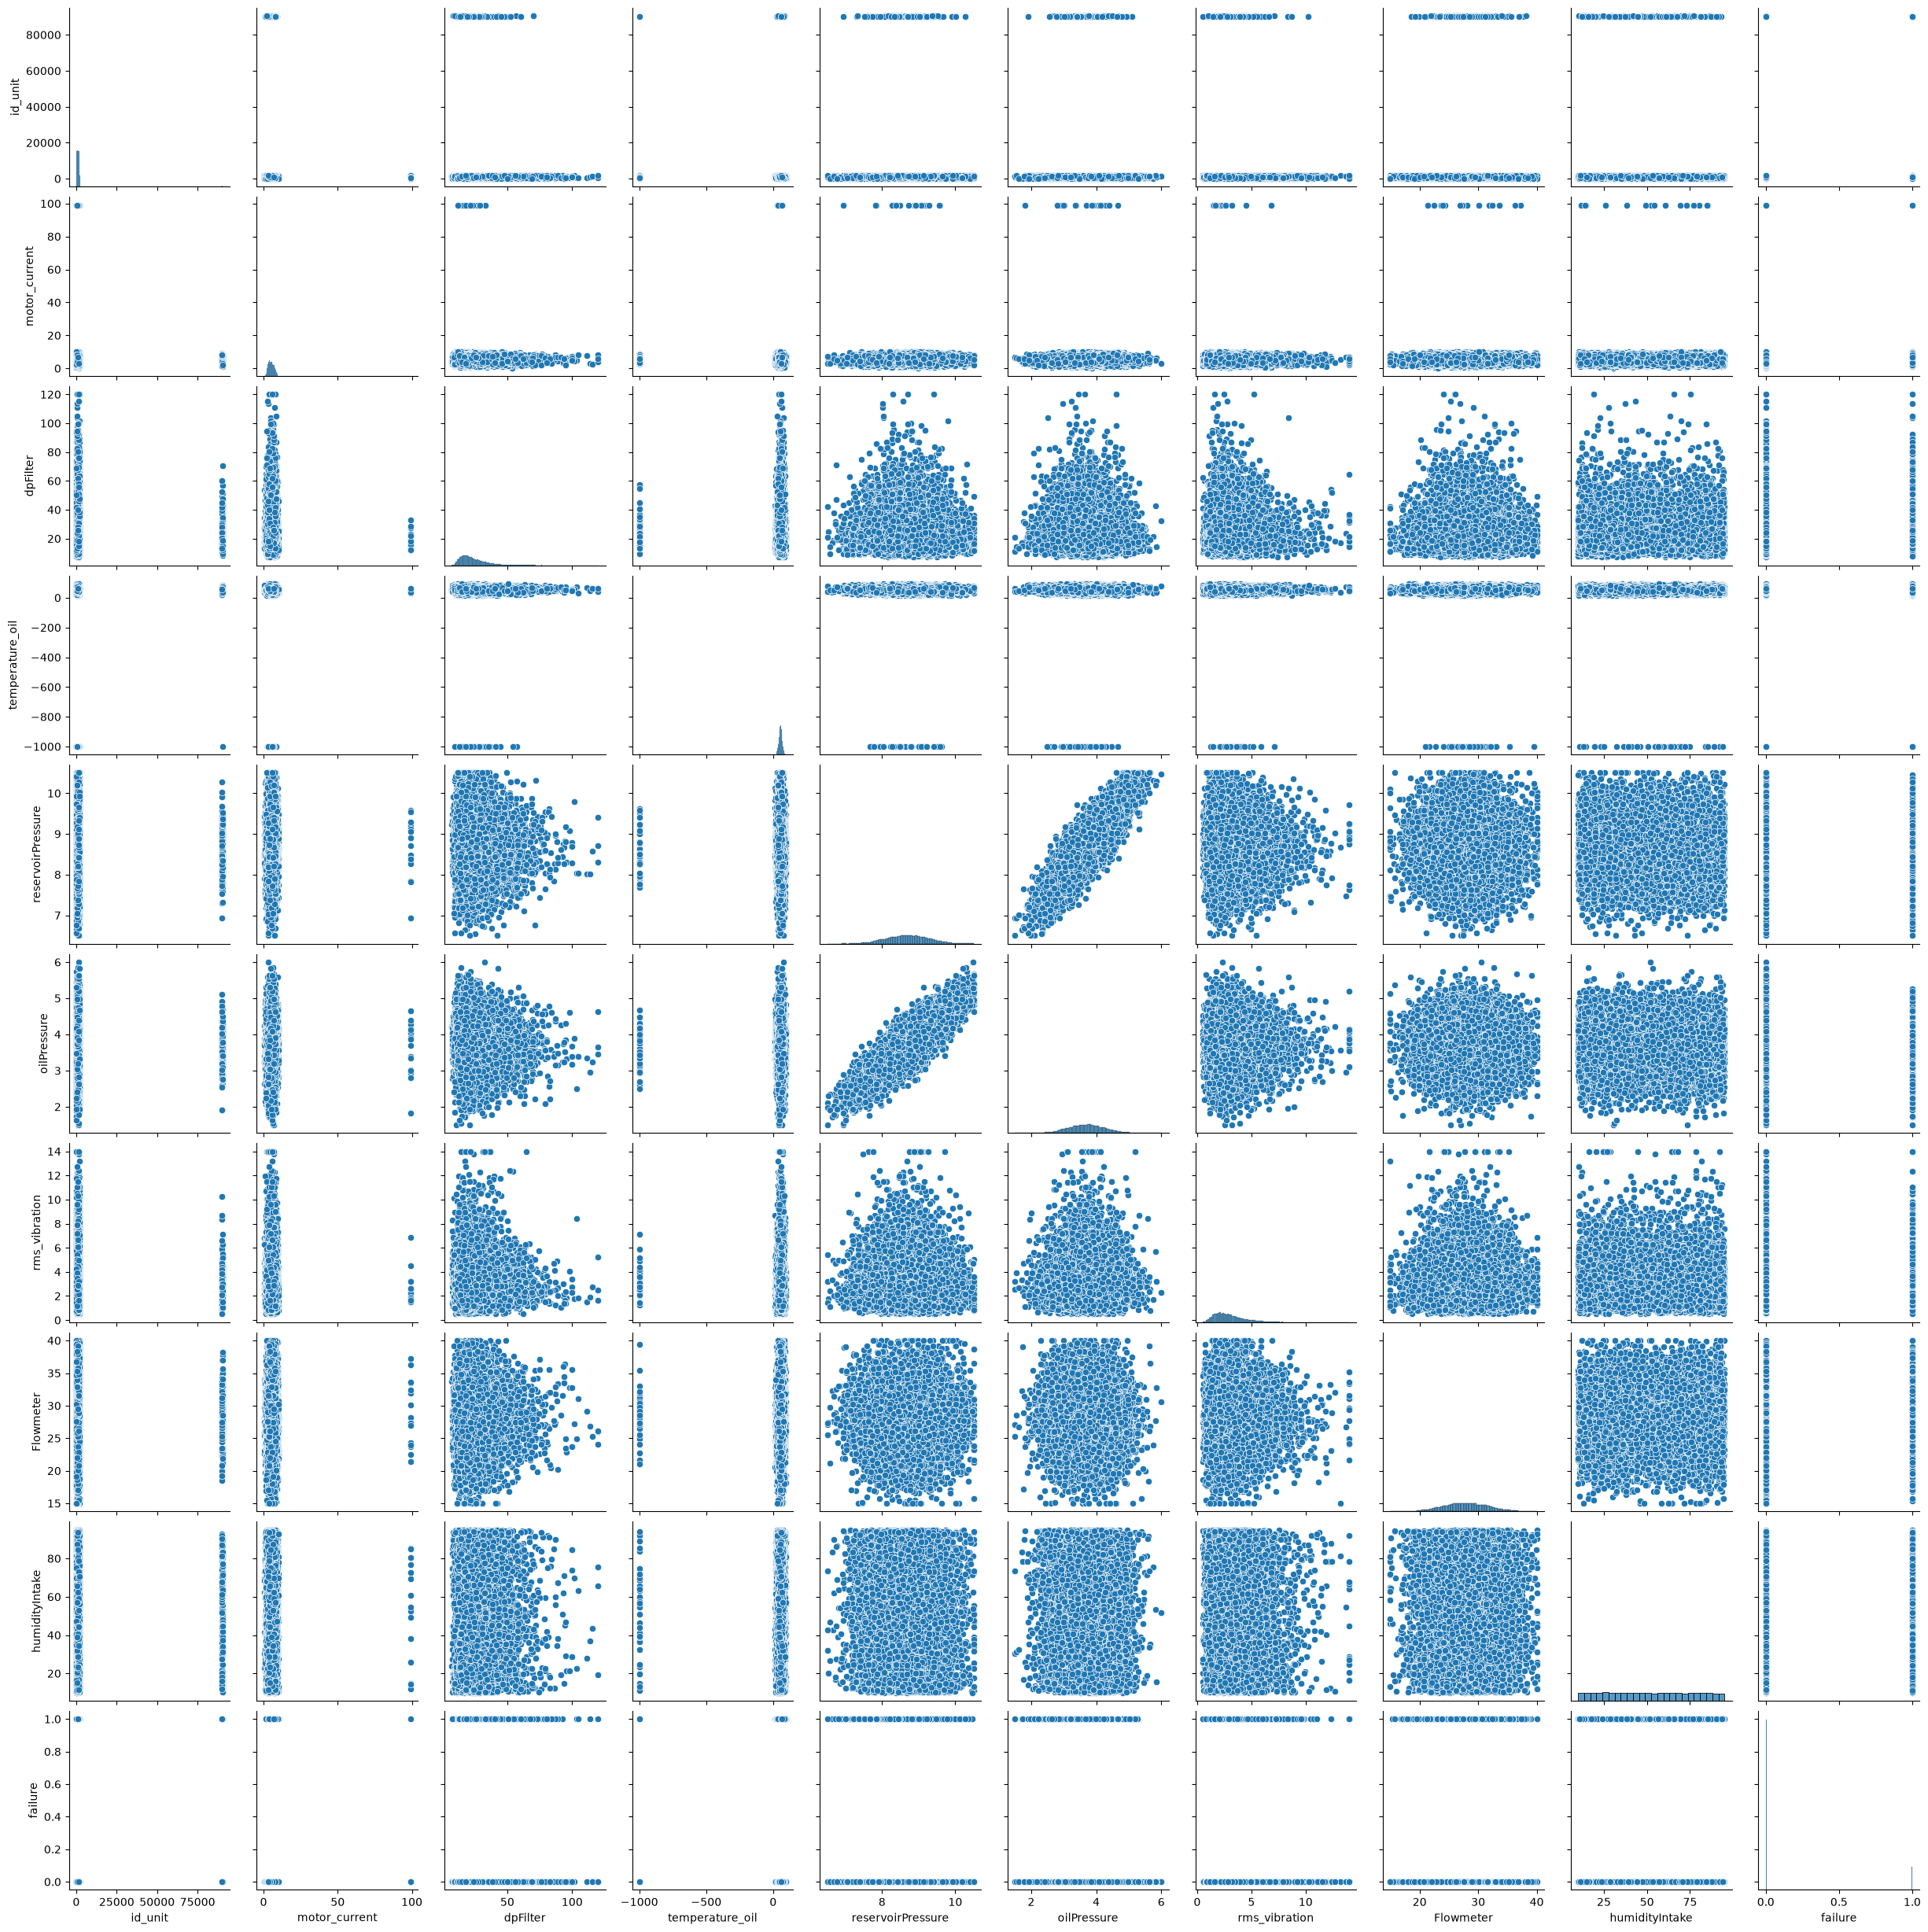

In [21]:
sns.pairplot(readings_df)

<Axes: xlabel='reservoirPressure', ylabel='oilPressure'>

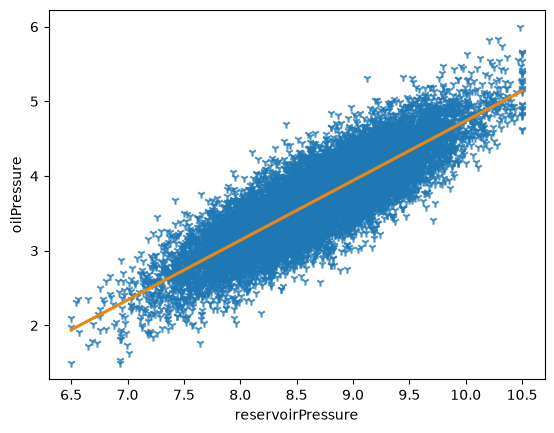

In [26]:
sns.regplot(x="reservoirPressure", y="oilPressure", data=readings_df, marker="1", line_kws={"color" : "#E88813"})